
================ DATA LOADING ================
(148519, 43)
Cleaned Shape: (148517, 43)
Selected Features: 85
Class Weights: {0: np.float64(0.3854874032736888), 1: np.float64(0.5563969279760232), 2: np.float64(2.1101678358937925), 3: np.float64(9.21031007751938), 4: np.float64(38.265056360708535)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        44,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,973 (828.02 KB)

 Trainable params: 210,437 (822.02 KB)

 Non-trainable params: 1,536 (6.00 KB)

None
Epoch 1/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8811 - loss: 0.3635 - val_accuracy: 0.9245 - val_loss: 0.2268
Epoch 2/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9278 - loss: 0.1941 - val_accuracy: 0.9482 - val_loss: 0.1666
Epoch 3/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9401 - loss: 0.1564 - val_accuracy: 0.9465 - val_loss: 0.1564
Epoch 4/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9448 - loss: 0.1407 - val_accuracy: 0.9500 - val_loss: 0.1439
Epoch 5/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9455 - loss: 0.1361 - val_accuracy: 0.9575 - val_loss: 0.1322
Epoch 6/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9504 - loss: 0.1241 - val_accuracy: 0.9612 - val_loss: 0.1231
Epoch 7/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9512 - loss: 0.1170 - val_accuracy: 0.9631 - val_loss: 0.1145
Epoch 8/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9544 - loss: 0.1077 - val_accura

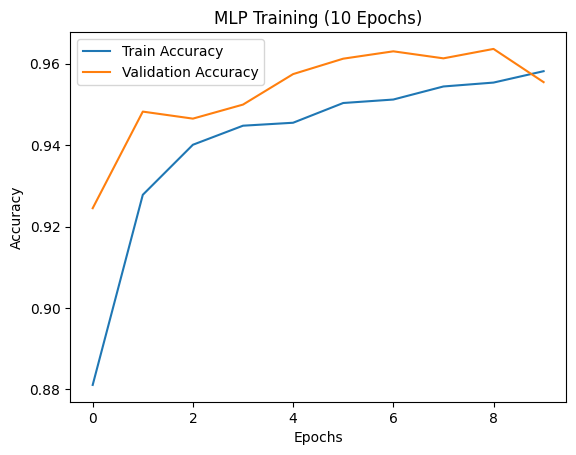


✅ MLP TRAINING COMPLETE


In [ ]:
# ======================= IMPORTS ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# ======================= LOAD DATA ===========================
print("\n================ DATA LOADING ================")

data = pd.read_csv(
    "/content/drive/MyDrive/dataset/NSL_KDD_Combined_Shuffled.csv",
    low_memory=False
)
print(data.shape)

# ======================= CLEAN DATA ===========================
data = data[data['duration'] != 'duration']

for col in data.columns:
    if col not in ['protocol_type', 'service', 'flag', 'label']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna()
print("Cleaned Shape:", data.shape)

# ======================= SPLIT ===========================
X = data.drop(columns=["label", "difficulty"])
y = data["label"]

# ======================= ATTACK MAPPING ===========================
dos = ['back','land','neptune','pod','smurf','teardrop','mailbomb','apache2','processtable','udpstorm']
probe = ['ipsweep','nmap','portsweep','satan','mscan','saint']
r2l = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster','sendmail','named']
u2r = ['buffer_overflow','loadmodule','perl','rootkit','httptunnel','ps','sqlattack','xterm']

def map_attack(x):
    if x == 'normal': return 0
    elif x in dos: return 1
    elif x in probe: return 2
    elif x in r2l: return 3
    else: return 4

y = y.apply(map_attack)

# ======================= TRAIN TEST SPLIT ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================= ENCODING ===========================
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test, columns=categorical_cols)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ======================= SCALING ===========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ======================= FEATURE SELECTION ===========================
mi_scores = mutual_info_classif(X_train_scaled, y_train)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": mi_scores
})

threshold = mi_df["Score"].quantile(0.3)
selected_features = mi_df[mi_df["Score"] > threshold]["Feature"]

print("Selected Features:", len(selected_features))

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Scale again
scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

# ======================= CLASS WEIGHTS ===========================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

# ======================= MLP MODEL ===========================
model = Sequential([
    Input(shape=(X_train_sel.shape[1],)),

    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(5, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

# ======================= TRAIN ===========================
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat  = to_categorical(y_test, num_classes=5)

history = model.fit(
    X_train_sel, y_train_cat,
    epochs=10,                 # 🔥 EXACTLY 10 EPOCHS
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

# ======================= PREDICTION ===========================
train_pred = np.argmax(model.predict(X_train_sel), axis=1)
test_pred  = np.argmax(model.predict(X_test_sel), axis=1)

# ======================= METRICS ===========================
train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred, average='weighted')
f1        = f1_score(y_test, test_pred, average='weighted')
cm        = confusion_matrix(y_test, test_pred)

# ======================= RESULTS ===========================
print("\n🔥 FINAL RESULTS 🔥")
print("Training Accuracy :", round(train_acc,4))
print("Testing Accuracy  :", round(test_acc,4))
print("Precision         :", round(precision,4))
print("F1 Score          :", round(f1,4))

print("\nConfusion Matrix:\n", cm)

# ======================= GRAPH ===========================
plt.figure()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("MLP Training (10 Epochs)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print("\n✅ MLP TRAINING COMPLETE")


================ DATA LOADING ================
Original Shape: (148519, 43)
Cleaned Shape: (148517, 43)
Selected Features: 85

🌐 Round 1/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 Round 1 Accuracy: 0.9515

🌐 Round 2/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
 Round 2 Accuracy: 0.9508

🌐 Round 3/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
 Round 3 Accuracy: 0.9536

🌐 Round 4/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
 Round 4 Accuracy: 0.9559

🌐 Round 5/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client

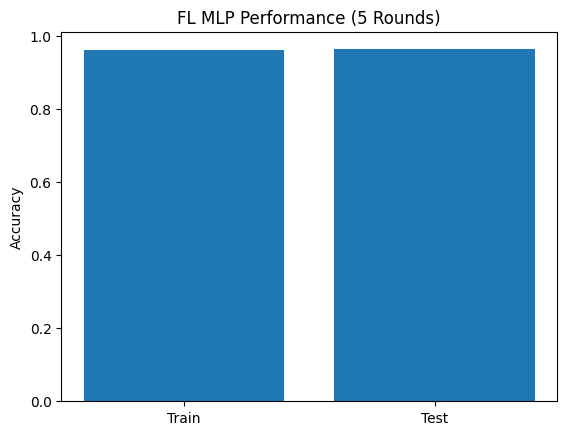

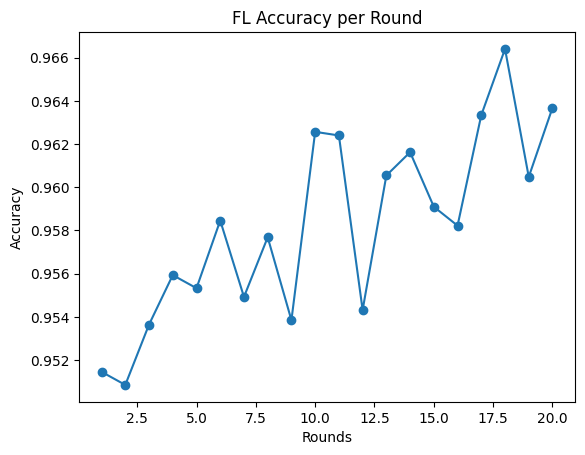


✅ FEDERATED MLP COMPLETE


In [ ]:
# ======================= IMPORTS ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# ======================= LOAD DATA ===========================
print("\n================ DATA LOADING ================")

data = pd.read_csv(
    "/content/drive/MyDrive/dataset/NSL_KDD_Combined_Shuffled.csv",
    low_memory=False
)

print("Original Shape:", data.shape)

# ======================= CLEAN DATA ===========================
data = data[data['duration'] != 'duration']

for col in data.columns:
    if col not in ['protocol_type', 'service', 'flag', 'label']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna()
print("Cleaned Shape:", data.shape)

# ======================= SPLIT ===========================
X = data.drop(columns=["label", "difficulty"])
y = data["label"]

# ======================= ATTACK MAPPING ===========================
dos = ['back','land','neptune','pod','smurf','teardrop','mailbomb','apache2','processtable','udpstorm']
probe = ['ipsweep','nmap','portsweep','satan','mscan','saint']
r2l = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster','sendmail','named']
u2r = ['buffer_overflow','loadmodule','perl','rootkit','httptunnel','ps','sqlattack','xterm']

def map_attack(x):
    if x == 'normal': return 0
    elif x in dos: return 1
    elif x in probe: return 2
    elif x in r2l: return 3
    else: return 4

y = y.apply(map_attack)

# ======================= TRAIN TEST SPLIT ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================= ENCODING ===========================
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test, columns=categorical_cols)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ======================= SCALING ===========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ======================= FEATURE SELECTION ===========================
mi_scores = mutual_info_classif(X_train_scaled, y_train)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": mi_scores
})

threshold = mi_df["Score"].quantile(0.3)
selected_features = mi_df[mi_df["Score"] > threshold]["Feature"]

print("Selected Features:", len(selected_features))

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Scale again
scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

# ======================= CLIENT SPLIT ===========================
NUM_CLIENTS = 5

client_data = []
client_sizes = []

size = len(X_train_sel) // NUM_CLIENTS

for i in range(NUM_CLIENTS):
    start = i * size
    end = (i + 1) * size if i != NUM_CLIENTS - 1 else len(X_train_sel)

    X_c = X_train_sel[start:end]
    y_c = y_train.iloc[start:end]

    client_data.append((X_c, y_c))
    client_sizes.append(len(X_c))

# ======================= MODEL ===========================
def create_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation='relu'),
        Dropout(0.2),

        Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0003),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ======================= WEIGHTED FEDAVG ===========================
def federated_avg(weights_list, client_sizes):
    avg_weights = []
    total = sum(client_sizes)

    for weights in zip(*weights_list):
        weighted_sum = sum(w * (size / total) for w, size in zip(weights, client_sizes))
        avg_weights.append(weighted_sum)

    return avg_weights

# ======================= TRAINING ===========================
ROUNDS = 20
LOCAL_EPOCHS = 5

global_model = create_model(X_train_sel.shape[1])
global_weights = global_model.get_weights()

round_acc = []

for r in range(ROUNDS):
    print(f"\n🌐 Round {r+1}/{ROUNDS}")

    local_weights = []

    for i, (X_c, y_c) in enumerate(client_data):
        print(f" Client {i+1} training...")

        local_model = create_model(X_train_sel.shape[1])
        local_model.set_weights(global_weights)

        y_c_cat = to_categorical(y_c, num_classes=5)

        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(y_c),
            y=y_c
        )
        class_weights = dict(enumerate(class_weights))

        local_model.fit(
            X_c, y_c_cat,
            epochs=LOCAL_EPOCHS,
            batch_size=64,
            verbose=0,
            class_weight=class_weights
        )

        local_weights.append(local_model.get_weights())

    # Aggregation
    global_weights = federated_avg(local_weights, client_sizes)
    global_model.set_weights(global_weights)

    # Evaluation
    y_pred = np.argmax(global_model.predict(X_test_sel), axis=1)
    acc = accuracy_score(y_test, y_pred)
    round_acc.append(acc)

    print(f" Round {r+1} Accuracy: {round(acc,4)}")

# ======================= FINAL RESULTS ===========================
train_pred = np.argmax(global_model.predict(X_train_sel), axis=1)
test_pred  = np.argmax(global_model.predict(X_test_sel), axis=1)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred, average='weighted')
f1        = f1_score(y_test, test_pred, average='weighted')
cm        = confusion_matrix(y_test, test_pred)

print("\n🔥 FINAL RESULTS 🔥")
print("Training Accuracy :", round(train_acc,4))
print("Testing Accuracy  :", round(test_acc,4))
print("Precision         :", round(precision,4))
print("F1 Score          :", round(f1,4))

print("\nConfusion Matrix:\n", cm)

# ======================= GRAPHS ===========================
plt.figure()
plt.bar(["Train", "Test"], [train_acc, test_acc])
plt.title("FL MLP Performance (5 Rounds)")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(range(1, ROUNDS+1), round_acc, marker='o')
plt.title("FL Accuracy per Round")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.show()

print("\n✅ FEDERATED MLP COMPLETE")


================ DATA LOADING ================
Original Shape: (148519, 43)
Cleaned Shape: (148517, 43)
Selected Features: 85

Round 1/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 Accuracy: 0.9497 | Loss: 0.1487

Round 2/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
 Accuracy: 0.9564 | Loss: 0.1392

Round 3/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
 Accuracy: 0.9515 | Loss: 0.1391

Round 4/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
 Accuracy: 0.956 | Loss: 0.1192

Round 5/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 tr

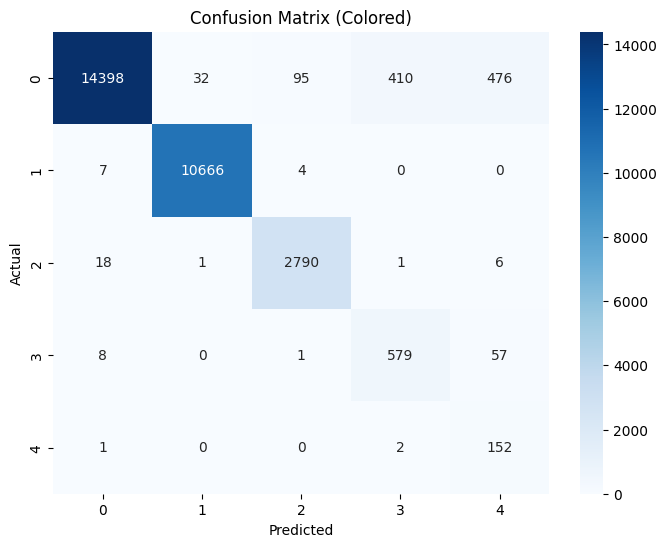

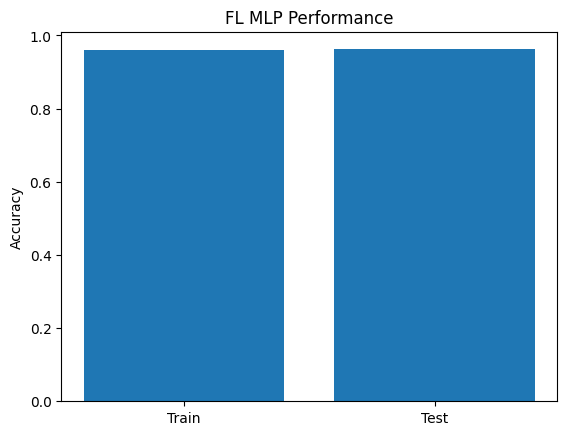

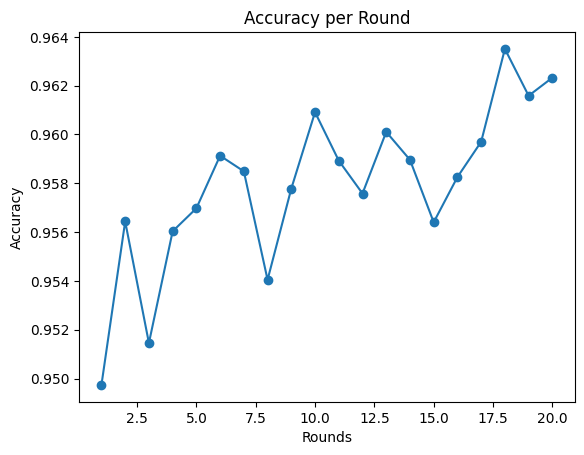

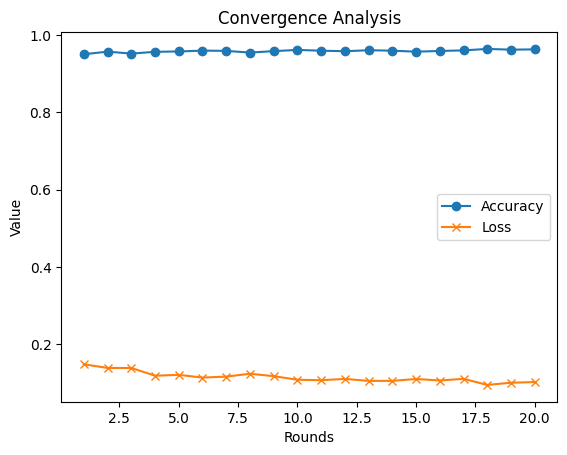


FEDERATED MLP COMPLETE


In [ ]:
# ======================= IMPORTS ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# ======================= LOAD DATA ===========================
print("\n================ DATA LOADING ================")

data = pd.read_csv(
    "/content/drive/MyDrive/dataset/NSL_KDD_Combined_Shuffled.csv",
    low_memory=False
)

print("Original Shape:", data.shape)

# ======================= CLEAN DATA ===========================
data = data[data['duration'] != 'duration']

for col in data.columns:
    if col not in ['protocol_type', 'service', 'flag', 'label']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna()
print("Cleaned Shape:", data.shape)

# ======================= SPLIT ===========================
X = data.drop(columns=["label", "difficulty"])
y = data["label"]

# ======================= ATTACK MAPPING ===========================
dos = ['back','land','neptune','pod','smurf','teardrop','mailbomb','apache2','processtable','udpstorm']
probe = ['ipsweep','nmap','portsweep','satan','mscan','saint']
r2l = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster','sendmail','named']
u2r = ['buffer_overflow','loadmodule','perl','rootkit','httptunnel','ps','sqlattack','xterm']

def map_attack(x):
    if x == 'normal': return 0
    elif x in dos: return 1
    elif x in probe: return 2
    elif x in r2l: return 3
    else: return 4

y = y.apply(map_attack)

# ======================= TRAIN TEST SPLIT ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================= ENCODING ===========================
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test, columns=categorical_cols)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ======================= SCALING ===========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ======================= FEATURE SELECTION ===========================
mi_scores = mutual_info_classif(X_train_scaled, y_train)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": mi_scores
})

threshold = mi_df["Score"].quantile(0.3)
selected_features = mi_df[mi_df["Score"] > threshold]["Feature"]

print("Selected Features:", len(selected_features))

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Scale again
scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

# ======================= CLIENT SPLIT ===========================
NUM_CLIENTS = 5

client_data = []
client_sizes = []

size = len(X_train_sel) // NUM_CLIENTS

for i in range(NUM_CLIENTS):
    start = i * size
    end = (i + 1) * size if i != NUM_CLIENTS - 1 else len(X_train_sel)

    X_c = X_train_sel[start:end]
    y_c = y_train.iloc[start:end]

    client_data.append((X_c, y_c))
    client_sizes.append(len(X_c))

# ======================= MODEL ===========================
def create_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation='relu'),
        Dropout(0.2),

        Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0003),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ======================= FEDAVG ===========================
def federated_avg(weights_list, client_sizes):
    avg_weights = []
    total = sum(client_sizes)

    for weights in zip(*weights_list):
        weighted_sum = sum(w * (size / total) for w, size in zip(weights, client_sizes))
        avg_weights.append(weighted_sum)

    return avg_weights

# ======================= TRAINING ===========================
ROUNDS = 20
LOCAL_EPOCHS = 5

global_model = create_model(X_train_sel.shape[1])
global_weights = global_model.get_weights()

round_acc = []
round_loss = []

for r in range(ROUNDS):
    print(f"\nRound {r+1}/{ROUNDS}")

    local_weights = []

    for i, (X_c, y_c) in enumerate(client_data):
        print(f" Client {i+1} training...")

        local_model = create_model(X_train_sel.shape[1])
        local_model.set_weights(global_weights)

        y_c_cat = to_categorical(y_c, num_classes=5)

        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(y_c),
            y=y_c
        )
        class_weights = dict(enumerate(class_weights))

        local_model.fit(
            X_c, y_c_cat,
            epochs=LOCAL_EPOCHS,
            batch_size=64,
            verbose=0,
            class_weight=class_weights
        )

        local_weights.append(local_model.get_weights())

    # Aggregation
    global_weights = federated_avg(local_weights, client_sizes)
    global_model.set_weights(global_weights)

    # Evaluation
    y_pred = np.argmax(global_model.predict(X_test_sel), axis=1)

    acc = accuracy_score(y_test, y_pred)
    loss = global_model.evaluate(
        X_test_sel,
        to_categorical(y_test, num_classes=5),
        verbose=0
    )[0]

    round_acc.append(acc)
    round_loss.append(loss)

    print(f" Accuracy: {round(acc,4)} | Loss: {round(loss,4)}")

# ======================= FINAL RESULTS ===========================
train_pred = np.argmax(global_model.predict(X_train_sel), axis=1)
test_pred  = np.argmax(global_model.predict(X_test_sel), axis=1)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred, average='weighted')
recall    = recall_score(y_test, test_pred, average='weighted')
f1        = f1_score(y_test, test_pred, average='weighted')

cm = confusion_matrix(y_test, test_pred)

print("\nFINAL RESULTS")
print("Training Accuracy :", round(train_acc,4))
print("Testing Accuracy  :", round(test_acc,4))
print("Precision         :", round(precision,4))
print("Recall            :", round(recall,4))
print("F1 Score          :", round(f1,4))

# ======================= CONFUSION MATRIX ===========================
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Colored)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ======================= GRAPHS ===========================

# Accuracy Comparison
plt.figure()
plt.bar(["Train", "Test"], [train_acc, test_acc])
plt.title("FL MLP Performance")
plt.ylabel("Accuracy")
plt.show()

# Accuracy per Round
plt.figure()
plt.plot(range(1, ROUNDS+1), round_acc, marker='o')
plt.title("Accuracy per Round")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.show()

# Convergence Graph (IMPORTANT)
plt.figure()
plt.plot(range(1, ROUNDS+1), round_acc, label='Accuracy', marker='o')
plt.plot(range(1, ROUNDS+1), round_loss, label='Loss', marker='x')
plt.title("Convergence Analysis")
plt.xlabel("Rounds")
plt.ylabel("Value")
plt.legend()
plt.show()

print("\nFEDERATED MLP COMPLETE")

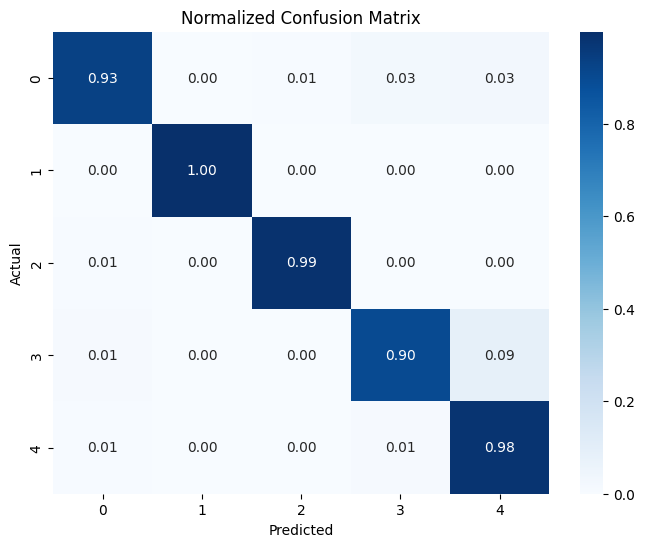

In [ ]:
cm_normalized = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8,6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues')
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


================ DATA LOADING ================
Original Shape: (148519, 43)
Cleaned Shape: (148517, 43)
Selected Features: 85

Round 1/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 Round 1 Accuracy: 0.9569

Round 2/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
 Round 2 Accuracy: 0.9641

Round 3/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
 Round 3 Accuracy: 0.9675

Round 4/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
 Round 4 Accuracy: 0.9703

Round 5/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 trainin

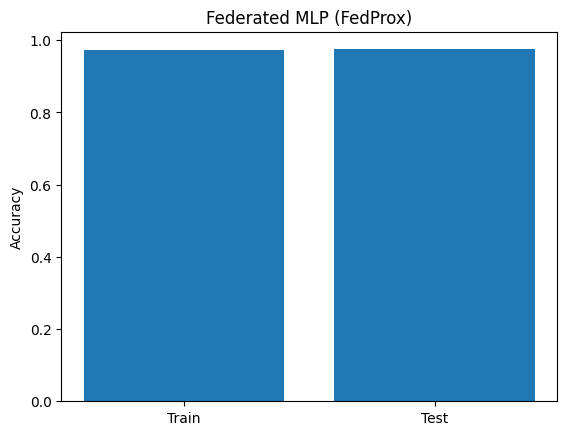

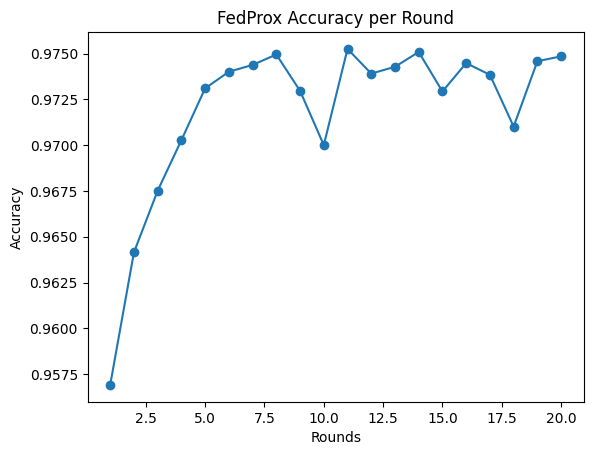


FEDERATED MLP WITH FEDPROX COMPLETE


In [ ]:
# ======================= IMPORTS ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# ======================= LOAD DATA ===========================
print("\n================ DATA LOADING ================")

data = pd.read_csv(
    "/content/drive/MyDrive/dataset/NSL_KDD_Combined_Shuffled.csv",
    low_memory=False
)

print("Original Shape:", data.shape)

# ======================= CLEAN DATA ===========================
data = data[data['duration'] != 'duration']

for col in data.columns:
    if col not in ['protocol_type', 'service', 'flag', 'label']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna()
print("Cleaned Shape:", data.shape)

# ======================= SPLIT ===========================
X = data.drop(columns=["label", "difficulty"])
y = data["label"]

# ======================= ATTACK MAPPING ===========================
dos = ['back','land','neptune','pod','smurf','teardrop','mailbomb','apache2','processtable','udpstorm']
probe = ['ipsweep','nmap','portsweep','satan','mscan','saint']
r2l = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster','sendmail','named']
u2r = ['buffer_overflow','loadmodule','perl','rootkit','httptunnel','ps','sqlattack','xterm']

def map_attack(x):
    if x == 'normal': return 0
    elif x in dos: return 1
    elif x in probe: return 2
    elif x in r2l: return 3
    else: return 4

y = y.apply(map_attack)

# ======================= TRAIN TEST SPLIT ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================= ENCODING ===========================
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test, columns=categorical_cols)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ======================= SCALING ===========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ======================= FEATURE SELECTION ===========================
mi_scores = mutual_info_classif(X_train_scaled, y_train)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": mi_scores
})

threshold = mi_df["Score"].quantile(0.3)
selected_features = mi_df[mi_df["Score"] > threshold]["Feature"]

print("Selected Features:", len(selected_features))

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Scale again
scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

# ======================= CLIENT SPLIT ===========================
NUM_CLIENTS = 5
client_data = []
client_sizes = []

size = len(X_train_sel) // NUM_CLIENTS

for i in range(NUM_CLIENTS):
    start = i * size
    end = (i + 1) * size if i != NUM_CLIENTS - 1 else len(X_train_sel)

    X_c = X_train_sel[start:end]
    y_c = y_train.iloc[start:end]

    client_data.append((X_c, y_c))
    client_sizes.append(len(X_c))

# ======================= MODEL (Layer Configurable) ===========================
def create_model(input_dim, layer_sizes=[512, 256, 128]):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for size in layer_sizes:
        model.add(Dense(size, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))

    model.add(Dense(5, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.0003),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ======================= FEDERATED AVG ===========================
def federated_avg(weights_list, client_sizes):
    avg_weights = []
    total = sum(client_sizes)

    for weights in zip(*weights_list):
        weighted_sum = sum(w * (size / total) for w, size in zip(weights, client_sizes))
        avg_weights.append(weighted_sum)

    return avg_weights

# ======================= TRAINING (FEDPROX) ===========================
ROUNDS = 20
LOCAL_EPOCHS = 5
MU = 0.01

global_model = create_model(X_train_sel.shape[1])
global_weights = global_model.get_weights()

round_acc = []

for r in range(ROUNDS):
    print(f"\nRound {r+1}/{ROUNDS}")

    local_weights = []

    for i, (X_c, y_c) in enumerate(client_data):
        print(f" Client {i+1} training...")

        local_model = create_model(X_train_sel.shape[1])
        local_model.set_weights(global_weights)

        y_c_cat = to_categorical(y_c, num_classes=5)

        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(y_c),
            y=y_c
        )
        class_weights = dict(enumerate(class_weights))

        # Local training
        local_model.fit(
            X_c, y_c_cat,
            epochs=LOCAL_EPOCHS,
            batch_size=64,
            verbose=0,
            class_weight=class_weights
        )

        # ===== FEDPROX UPDATE =====
        new_weights = local_model.get_weights()
        updated_weights = []

        for w, w_global in zip(new_weights, global_weights):
            updated_weights.append(
                w - MU * (w - w_global)
            )

        local_model.set_weights(updated_weights)
        local_weights.append(local_model.get_weights())

    # Aggregation
    global_weights = federated_avg(local_weights, client_sizes)
    global_model.set_weights(global_weights)

    # Evaluation
    y_pred = np.argmax(global_model.predict(X_test_sel), axis=1)
    acc = accuracy_score(y_test, y_pred)
    round_acc.append(acc)

    print(f" Round {r+1} Accuracy: {round(acc,4)}")

# ======================= FINAL RESULTS ===========================
train_pred = np.argmax(global_model.predict(X_train_sel), axis=1)
test_pred  = np.argmax(global_model.predict(X_test_sel), axis=1)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred, average='weighted')
f1        = f1_score(y_test, test_pred, average='weighted')
cm        = confusion_matrix(y_test, test_pred)

print("\nFINAL MLP FL RESULTS")
print("Training Accuracy :", round(train_acc,4))
print("Testing Accuracy  :", round(test_acc,4))
print("Precision         :", round(precision,4))
print("F1 Score          :", round(f1,4))

print("\nConfusion Matrix:\n", cm)

# ======================= GRAPHS ===========================
plt.figure()
plt.bar(["Train", "Test"], [train_acc, test_acc])
plt.title("Federated MLP (FedProx)")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(range(1, ROUNDS+1), round_acc, marker='o')
plt.title("FedProx Accuracy per Round")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.show()

print("\nFEDERATED MLP WITH FEDPROX COMPLETE")


🔥 FINAL RESULTS (MLP FEDPROX) 🔥
Training Accuracy : 0.974
Testing Accuracy  : 0.9749
Precision         : 0.9839
Recall            : 0.9749
F1 Score          : 0.9778

Confusion Matrix:
 [[14718    30    93   312   258]
 [    8 10665     4     0     0]
 [   12     1  2798     2     3]
 [   13     0     1   626     5]
 [    2     0     0     3   150]]


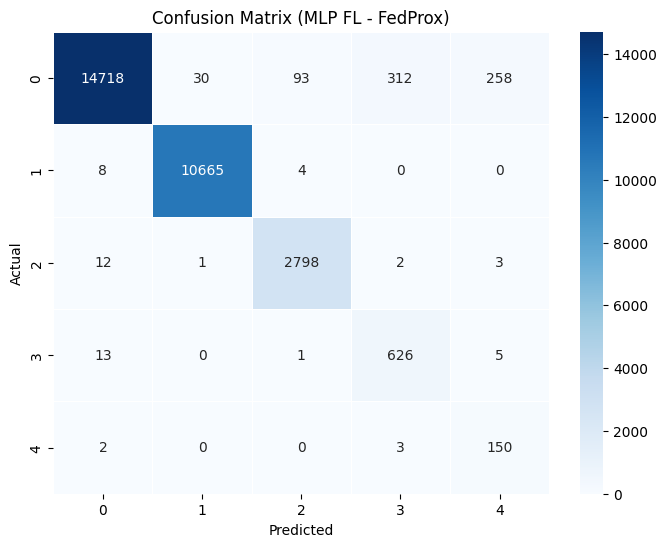

In [ ]:
# ======================= FINAL RESULTS (MLP FL - STATIC) ===========================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ======================= GIVEN RESULTS ===========================
train_acc = 0.974
test_acc  = 0.9749
precision = 0.9839
f1        = 0.9778

# Confusion Matrix (your result)
cm = np.array([
    [14718,   30,   93,  312,  258],
    [    8, 10665,   4,    0,    0],
    [   12,    1, 2798,   2,    3],
    [   13,    0,   1,  626,    5],
    [    2,    0,   0,    3,  150]
])

# ======================= RECALL FROM CM ===========================
recall_per_class = np.diag(cm) / np.sum(cm, axis=1)
support = np.sum(cm, axis=1)
recall = np.sum(recall_per_class * support) / np.sum(support)

# ======================= PRINT RESULTS ===========================
print("\n🔥 FINAL RESULTS (MLP FEDPROX) 🔥")
print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)
print("Precision         :", precision)
print("Recall            :", round(recall, 4))
print("F1 Score          :", f1)

print("\nConfusion Matrix:\n", cm)

# ======================= HEATMAP ===========================
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)

plt.title("Confusion Matrix (MLP FL - FedProx)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()